# Notebok 1 - Data

Downloads Eurostat route data, builds the route panel, classifies routes by FIR airspace transit, and saves parquet files.

## 1. Imports and directories

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math, warnings, requests, time, os
import json
import matplotlib.patches as mpatches
from shapely.geometry import Polygon, Point, box as sbox
from shapely.ops import unary_union
from shapely.validation import make_valid
from io import StringIO
from pathlib import Path
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})
C = {'primary':'#1A4A8A','secondary':'#C0392B','neutral':'#888780','highlight':'#2DBDB6'}

RAW_DIR   = Path.home() / 'econ62020' / 'raw'
CLEAN_DIR = Path.home() / 'econ62020' / 'clean'

ROUTE_DIR = RAW_DIR / 'avia_par'
OUTPUT_DIR = CLEAN_DIR
for d in [RAW_DIR, ROUTE_DIR, CLEAN_DIR]:
    d.mkdir(parents=True, exist_ok=True)

## 2. Geographic lookups

Hub coordinates kept for reference/map drawing. Route classification uses airport coordinates (Section 7).

In [2]:
EUROPEAN_DESTS = {
    'AL','AT','BA','BE','BG','CH','CY','CZ','DE','DK','EE','ES','FI','FR','GB',
    'GR','HR','HU','IE','IS','IT','LI','LT','LU','LV','MD','ME','MK','MT','NL',
    'NO','PL','PT','RO','RS','SE','SI','SK','SM','XK',
}

# Kept for map drawing only — not used for treatment classification
HUBS = {
    'AL':(41.41,19.72),'AT':(48.11,16.57),'BE':(50.90,4.48),'BG':(42.70,23.41),
    'CH':(47.46,8.55),'CY':(34.87,33.63),'CZ':(50.10,14.26),'DE':(50.03,8.57),
    'DK':(55.62,12.66),'EE':(59.41,24.83),'ES':(40.47,-3.56),'FI':(60.32,24.96),
    'FR':(49.01,2.55),'GB':(51.48,-0.45),'GE':(41.67,44.95),'GR':(37.94,23.95),
    'HR':(45.74,16.07),'HU':(47.43,19.26),'IE':(53.42,-6.27),'IT':(41.80,12.25),
    'LT':(54.64,25.28),'LV':(56.92,23.97),'MD':(46.93,28.93),'MK':(41.96,21.62),
    'MT':(35.86,14.48),'NL':(52.31,4.77),'NO':(60.20,11.08),'PL':(52.17,20.97),
    'PT':(38.77,-9.13),'RO':(44.57,26.10),'RS':(44.82,20.29),'SE':(59.65,17.92),
    'SI':(46.22,14.46),'SK':(48.17,17.21),'TR':(40.98,28.82),
}

EUROSTAT_CODE_MAP = {'UK':'GB','EL':'GR','XK':'RS'}

## 3. Route classification functions

FIR polygons (Russia and Ukraine) and great-circle path transit checks.

In [3]:
def haversine_vec(lat1, lon1, lat2, lon2):
    R = 6371
    phi1,phi2 = np.radians(lat1),np.radians(lat2)
    dphi,dlam = np.radians(lat2-lat1),np.radians(lon2-lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def great_circle_points(lat1,lon1,lat2,lon2,n=100):
    lat1,lon1,lat2,lon2 = map(math.radians,[lat1,lon1,lat2,lon2])
    d = math.acos(max(-1,min(1,math.sin(lat1)*math.sin(lat2)+math.cos(lat1)*math.cos(lat2)*math.cos(lon2-lon1))))
    if d==0: return []
    pts=[]
    for i in range(1,n):
        f=i/n; A=math.sin((1-f)*d)/math.sin(d); B=math.sin(f*d)/math.sin(d)
        x=A*math.cos(lat1)*math.cos(lon1)+B*math.cos(lat2)*math.cos(lon2)
        y=A*math.cos(lat1)*math.sin(lon1)+B*math.cos(lat2)*math.sin(lon2)
        z=A*math.sin(lat1)+B*math.sin(lat2)
        pts.append((math.degrees(math.atan2(z,math.sqrt(x**2+y**2))),math.degrees(math.atan2(y,x))))
    return pts

def transits_fir(lat1,lon1,lat2,lon2,poly,n=100):
    """Returns True if the great-circle path passes through the FIR polygon."""
    return any(poly.contains(Point(lon,lat)) for lat,lon in great_circle_points(lat1,lon1,lat2,lon2,n))

In [4]:
# Russia FIR — union of main FIR and Moscow FIR
RUSSIA_FIR = unary_union([Polygon([
    (98,51),(98.28,50.35),(97,49.83),(87,49),(86.4,50.05),(84.88,49.8),(83,51),(80.5,51),(79.85,51.03),
    (76.5,54.33),(74,53.83),(73.25,53.93),(71,54.75),(70.63,55.42),(61.13,53.88),(60.98,53.92),
    (59.38,53.89),(58.8,54.03),(57.88,55.7),(56.08,56.5),(53.67,56.5),(52.2,56.42),(51.88,56.37),
    (50.8,56.47),(47.92,57.3),(46.75,57.23),(46.95,58.17),(45,58.78),(39.43,58.72),(39.33,58.72),
    (38.06,58.7),(37.98,58.7),(35.83,58.58),(35.98,59.37),(35.86,59.87),(35.84,59.97),(35.62,60.85),
    (36.65,61.25),(37.3,61.33),(36.43,63.83),(35.72,65.02),(36.9,66.28),(38.33,66.05),(40,66.25),
    (42.5,66.78),(43.27,68.67),(49.12,69.5),(48,70.37),(48,82),(48,89),(179,89),(179,50),(157,50),
    (150,47),(145,44.67),(141,46),(137,38.67),(128.5,38.67),(127.67,39.6),(129.5,40.75),(130.67,42.33),
    (131.58,45.17),(133,45),(135,48.5),(131,47.83),(127.5,49.92),(126,52.67),(124,53.5),(120,53),
    (119.33,50.25),(118,49.5),(114,50),(110,49),(99,52),(98,51)
]),Polygon([
    (30.95,55.58),(30.49,55.8),(30.02,55.87),(29.49,55.71),(29.4,55.97),(28.15,56.17),(28.2,56.36),
    (28.13,56.51),(27.9,56.75),(27.69,57.38),(27.7,57.55),(27.38,57.6),(27.56,57.83),(27.82,57.9),
    (28.73,58.28),(28.89,58.32),(29.9,58.53),(31.25,58.15),(32.82,58.05),(33.33,57.67),(33.72,57.82),
    (33.9,57.98),(34.13,58.08),(34.36,58.15),(35.83,58.58),(37.98,58.7),(38.06,58.7),(39.33,58.72),
    (39.43,58.72),(45,58.78),(46.95,58.17),(46.75,57.23),(46.43,55.6),(46.58,54.82),(43.85,54.63),
    (42.47,53.5),(42.87,52.33),(42.58,51.53),(43.03,50.75),(41.84,50.19),(41.42,49.97),(41.08,49.83),
    (40.47,49.53),(40.12,49.61),(39.5,49.74),(38.23,50.08),(38.19,50.07),(38.18,49.95),(38.15,49.93),
    (38.04,49.91),(37.76,50.09),(37.64,50.3),(37.47,50.43),(36.83,50.32),(36.49,50.31),(36.41,50.32),
    (36.29,50.32),(35.7,50.36),(35.65,50.37),(35.45,50.82),(35.43,50.85),(35.33,51.07),(34.45,51.23),
    (34.08,51.65),(34.5,51.7),(34.17,51.97),(34.12,52),(33.9,52.32),(33.31,52.35),(32.67,52.28),
    (32.33,52.3),(32.25,52.1),(31.95,52.08),(31.55,52.65),(31.36,52.97),(32.46,53.22),(32.27,53.5),
    (31.49,54.09),(31.38,54.22),(31.13,54.37),(31.08,54.5),(31.04,54.67),(30.96,55.19),(30.86,55.28),(30.95,55.58)
])])

def _ep(g):
    if g.geom_type=='Polygon': return [g]
    return [p for sg in getattr(g,'geoms',[]) for p in _ep(sg) if hasattr(p,'exterior')]

UKRAINE_FIR = unary_union(_ep(make_valid(Polygon([
    (22.14,48.46),(22.35,48.77),(22.57,49.09),(22.83,49.09),(22.66,49.5),(22.94,49.81),
    (23.49,50.22),(24.07,50.5),(24.1,50.83),(23.65,51.3),(24.69,51.9),(26.12,51.89),
    (27.7,51.48),(28.68,51.56),(29.33,51.57),(30.56,51.26),(30.63,51.72),(31.95,52.08),
    (32.67,52.28),(33.9,52.32),(34.5,51.7),(35.45,50.82),(36.83,50.32),(38.23,50.08),
    (39.5,49.74),(39.86,48.52),(39.22,47.86),(38.31,47.56),(37.37,46.57),(36.54,45.2),
    (36.8,45.64),(37.37,46.57),(36.01,46.97),(35.26,47.2),(33.92,47.59),(32.83,47.77),
    (32.67,48.36),(33.37,48.95),(33.89,50.21),(34.45,51.23),(32.5,45.91),(30.56,44.98),
    (30.08,44.91),(30.75,42.8),(35,42.75),(36.67,44.52),(36.8,45.64),(29.69,46.36),(22.14,48.46)
]))))

print(f'Russia FIR valid: {RUSSIA_FIR.is_valid}  Ukraine FIR valid: {UKRAINE_FIR.is_valid}')

Russia FIR valid: True  Ukraine FIR valid: True


## 4. Download avia_par (Eurostat route passenger data)

Downloads one TSV per country.

In [5]:
COUNTRIES_USE = [
    'at','be','bg','ch','cy','de','dk','ee','es','fi','fr','gb',
    'gr','hr','hu','ie','it','lt','lv','mk','mt','nl','no',
    'pl','pt','ro','rs','se','si','sk','tr'
]
# Note: GB monthly data ends 2019-12 due to Brexit reporting changes.
# GB is dropped from post-closure specs in the analysis notebook.

def download_avia_par(iso2, save_dir, retries=3):
    dataset   = f'avia_par_{iso2}'
    url       = ('https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/'
                 f'{dataset}?format=TSV&compressed=false')
    save_path = save_dir / f'{dataset}.tsv'
    if save_path.exists():
        print(f'{iso2.upper()}: already downloaded, skipping'); return True
    for attempt in range(retries):
        try:
            print(f'{iso2.upper()}: downloading...', end=' ')
            resp = requests.get(url, timeout=120)
            if resp.status_code == 200:
                save_path.write_text(resp.text, encoding='utf-8')
                print(f'OK ({len(resp.text.strip().splitlines()):,} rows)'); return True
            elif resp.status_code == 404:
                print('NOT FOUND'); return False
            else:
                print(f'HTTP {resp.status_code}'); time.sleep(5)
        except Exception as e:
            print(f'Error: {e}'); time.sleep(5)
    return False

results = {iso2: download_avia_par(iso2, ROUTE_DIR) for iso2 in COUNTRIES_USE}

# Eurostat uses 'el' for Greece and 'uk' for GB
for ec, std in [('el','gr'),('uk','gb')]:
    dst = ROUTE_DIR / f'avia_par_{std}.tsv'
    if not dst.exists():
        download_avia_par(ec, ROUTE_DIR)
        src = ROUTE_DIR / f'avia_par_{ec}.tsv'
        if src.exists(): os.rename(src, dst)

print(f'\nDone: {sum(results.values())}/{len(results)} successful')

AT: already downloaded, skipping
BE: already downloaded, skipping
BG: already downloaded, skipping
CH: already downloaded, skipping
CY: already downloaded, skipping
DE: already downloaded, skipping
DK: already downloaded, skipping
EE: already downloaded, skipping
ES: already downloaded, skipping
FI: already downloaded, skipping
FR: already downloaded, skipping
GB: already downloaded, skipping
GR: already downloaded, skipping
HR: already downloaded, skipping
HU: already downloaded, skipping
IE: already downloaded, skipping
IT: already downloaded, skipping
LT: already downloaded, skipping
LV: already downloaded, skipping
MK: already downloaded, skipping
MT: already downloaded, skipping
NL: already downloaded, skipping
NO: already downloaded, skipping
PL: already downloaded, skipping
PT: already downloaded, skipping
RO: already downloaded, skipping
RS: already downloaded, skipping
SE: already downloaded, skipping
SI: already downloaded, skipping
SK: already downloaded, skipping
TR: alread

## 5. Parse and build the route panel

Extracts monthly data from 2015+, melts to long format, pivots three measures into columns: FLIGHTS, PASSENGERS, SEATS.

In [6]:
def parse_avia_par(iso2, route_dir):
    fpath = route_dir / f'avia_par_{iso2}.tsv'
    if not fpath.exists(): return None
    df_raw = pd.read_csv(fpath, sep='\t',
        na_values=[':', ': ', 'z', 'Z', 'zp', 'ep', 'p', 'b', 'bd', ': z', ': b', ': ep', ': p'],
        low_memory=False)
    all_cols  = df_raw.columns.tolist()
    time_cols = [c for c in all_cols if str(c).strip().count('-')==1
                 and len(str(c).strip())==7
                 and not str(c).strip().endswith(('Q1','Q2','Q3','Q4'))
                 and int(str(c).strip()[:4])>=2015]
    if not time_cols: return None
    kp = df_raw[all_cols[0]].astype(str).str.strip().str.split(',', expand=True)
    df_raw['FREQ']     = kp[0].str.strip()
    df_raw['TRA_MEAS'] = kp[2].str.strip()
    df_raw['AIRP_PR']  = kp[3].str.strip().str.split('\\').str[0].str.strip()
    df_raw['ISO2']     = iso2.upper()
    df_filt = df_raw[(df_raw['FREQ']=='M') &
                     (df_raw['TRA_MEAS'].isin(['CAF_PAS','PAS_CRD','ST_PAS']))]                    [['ISO2','TRA_MEAS','AIRP_PR']+time_cols].copy()
    if df_filt.empty: return None
    df_long = df_filt.melt(id_vars=['ISO2','TRA_MEAS','AIRP_PR'],
                           value_vars=time_cols, var_name='TIME_STR', value_name='VALUE')
    df_long['YEAR']  = df_long['TIME_STR'].str[:4].astype(int)
    df_long['MONTH'] = df_long['TIME_STR'].str[5:7].astype(int)
    df_long['VALUE'] = pd.to_numeric(
        df_long['VALUE'].astype(str).str.replace(r'[a-zA-Z\s]','',regex=True).replace('',np.nan),
        errors='coerce')
    return df_long.dropna(subset=['VALUE'])

dfs = []
for iso2 in COUNTRIES_USE:
    df = parse_avia_par(iso2, ROUTE_DIR)
    if df is not None:
        dfs.append(df)
        print(f'{iso2.upper()}: {len(df):,} rows')

df_all = pd.concat(dfs, ignore_index=True)
print(f'\nTotal rows: {df_all.shape}  |  {df_all["YEAR"].min()}–{df_all["YEAR"].max()}')

AT: 42,941 rows
BE: 53,962 rows
BG: 28,289 rows
CH: 66,058 rows
CY: 23,299 rows
DE: 291,891 rows
DK: 44,662 rows
EE: 9,744 rows
ES: 321,115 rows
FI: 26,483 rows
FR: 260,481 rows
GB: 199,778 rows
GR: 88,445 rows
HR: 33,429 rows
HU: 20,894 rows
IE: 47,393 rows
IT: 298,230 rows
LT: 21,736 rows
LV: 14,825 rows
MK: 11,274 rows
MT: 17,272 rows
NL: 87,751 rows
NO: 65,749 rows
PL: 119,940 rows
PT: 77,197 rows
RO: 51,737 rows
RS: 16,664 rows
SE: 58,242 rows
SI: 5,950 rows
SK: 10,229 rows
TR: 156,310 rows

Total rows: (2571970, 7)  |  2015–2024


In [7]:
# Pivot measures into columns
df_pivot = df_all.pivot_table(
    index=['ISO2','AIRP_PR','YEAR','MONTH'], columns='TRA_MEAS',
    values='VALUE', aggfunc='sum'
).reset_index()
df_pivot.columns.name = None
df_pivot = df_pivot.rename(columns={'CAF_PAS':'FLIGHTS','PAS_CRD':'PASSENGERS','ST_PAS':'SEATS'})
if {'PASSENGERS','SEATS'}.issubset(df_pivot.columns):
    df_pivot['LOAD_FACTOR'] = (df_pivot['PASSENGERS']/df_pivot['SEATS']).clip(0,1)

# Parse route codes: CC_ICAO_CC_ICAO
parsed = df_pivot['AIRP_PR'].str.split('_', expand=True)
df_pivot[['ORIG_CC','ORIG_ICAO','DEST_CC','DEST_ICAO']] = parsed[[0,1,2,3]]
df_pivot['ORIG_CC'] = df_pivot['ORIG_CC'].replace(EUROSTAT_CODE_MAP)
df_pivot['DEST_CC'] = df_pivot['DEST_CC'].replace(EUROSTAT_CODE_MAP)

# Time variables
df_pivot['DATE']  = pd.to_datetime(df_pivot['YEAR'].astype(str)+'-'+df_pivot['MONTH'].astype(str).str.zfill(2)+'-01')
df_pivot['POST']  = (((df_pivot['YEAR']==2022)&(df_pivot['MONTH']>=2))|(df_pivot['YEAR']>=2023)).astype(int)
df_pivot['COVID'] = df_pivot['YEAR'].isin([2020,2021]).astype(int)
df_pivot['TIME']  = df_pivot['YEAR']*100 + df_pivot['MONTH']

# Log outcomes
for col,lc in [('FLIGHTS','LOG_FLIGHTS'),('PASSENGERS','LOG_PASSENGERS'),('SEATS','LOG_SEATS')]:
    df_pivot[lc] = np.log(df_pivot[col].replace(0,np.nan))

print(f'Pivoted panel: {df_pivot.shape}')
print(f'Unique origin airports: {df_pivot["ORIG_ICAO"].nunique():,}')

Pivoted panel: (885377, 19)
Unique origin airports: 370


## 6. Airport coordinates and route distances

Downloads airport lat/lon from OurAirports and merges onto panel.

In [8]:
resp = requests.get('https://ourairports.com/data/airports.csv', timeout=60)
airports_df = pd.read_csv(StringIO(resp.text))[['ident','latitude_deg','longitude_deg']]    .rename(columns={'ident':'ICAO','latitude_deg':'LAT','longitude_deg':'LON'}).dropna()
print(f'Loaded {len(airports_df):,} airports')

def add_coords_dist(df):
    df = df.merge(
        airports_df.rename(columns={'ICAO':'ORIG_ICAO','LAT':'ORIG_LAT','LON':'ORIG_LON'}),
        on='ORIG_ICAO', how='left'
    ).merge(
        airports_df.rename(columns={'ICAO':'DEST_ICAO','LAT':'DEST_LAT','LON':'DEST_LON'}),
        on='DEST_ICAO', how='left'
    )
    df['ROUTE_DIST_KM'] = haversine_vec(
        df['ORIG_LAT'].values, df['ORIG_LON'].values,
        df['DEST_LAT'].values, df['DEST_LON'].values)
    return df

df_pivot = add_coords_dist(df_pivot)
print(f'Coordinates matched: {df_pivot["ORIG_LAT"].notna().mean()*100:.1f}%')
print(f'Distance computed:   {df_pivot["ROUTE_DIST_KM"].notna().mean()*100:.1f}%')

Loaded 85,408 airports
Coordinates matched: 99.5%
Distance computed:   98.6%


## 7. Route classification

Classifies each unique airport pair using FIR polygons and great-circle paths.
Intra-European routes and routes with missing coordinates are marked unaffected.

In [9]:
unique_routes = df_pivot[['AIRP_PR','ORIG_ICAO','DEST_ICAO',
                           'ORIG_CC','DEST_CC',
                           'ORIG_LAT','ORIG_LON',
                           'DEST_LAT','DEST_LON']].drop_duplicates('AIRP_PR')

route_flags = {}

for _, row in unique_routes.iterrows():
    if row.DEST_CC in EUROPEAN_DESTS:
        route_flags[row.AIRP_PR] = (False, False)
        continue
    if pd.isna(row.ORIG_LAT) or pd.isna(row.DEST_LAT):
        route_flags[row.AIRP_PR] = (False, False)
        continue
    olat,olon = row.ORIG_LAT, row.ORIG_LON
    dlat,dlon = row.DEST_LAT, row.DEST_LON
    route_flags[row.AIRP_PR] = (
        transits_fir(olat,olon,dlat,dlon,RUSSIA_FIR),
        transits_fir(olat,olon,dlat,dlon,UKRAINE_FIR)
    )

df_pivot['HITS_RUSSIA']  = df_pivot['AIRP_PR'].map(lambda x: route_flags.get(x,(False,False))[0])
df_pivot['HITS_UKRAINE'] = df_pivot['AIRP_PR'].map(lambda x: route_flags.get(x,(False,False))[1])
df_pivot['AFFECTED']     = df_pivot['HITS_RUSSIA'] | df_pivot['HITS_UKRAINE']

df_pivot['DID']         = df_pivot['AFFECTED'].astype(int) * df_pivot['POST']
df_pivot['DID_RUSSIA']  = (df_pivot['HITS_RUSSIA']  & ~df_pivot['HITS_UKRAINE']).astype(int) * df_pivot['POST']
df_pivot['DID_UKRAINE'] = (df_pivot['HITS_UKRAINE'] & ~df_pivot['HITS_RUSSIA']).astype(int)  * df_pivot['POST']
df_pivot['DID_BOTH']    = (df_pivot['HITS_RUSSIA']  &  df_pivot['HITS_UKRAINE']).astype(int) * df_pivot['POST']

route_panel_nc = df_pivot[~df_pivot['YEAR'].isin([2020,2021])].copy()
route_panel_nc = route_panel_nc[
    ~((route_panel_nc['ISO2']=='GB') & (route_panel_nc['YEAR']>=2020))
].copy()

print(f'Treated routes:  {df_pivot[df_pivot["AFFECTED"]]["AIRP_PR"].nunique():,}')
print(f'route_panel_nc:  {route_panel_nc.shape}')

Treated routes:  718
route_panel_nc:  (783057, 31)


## 8. Route classification map

FIR boundaries and great-circle paths. Intra-European routes excluded as unaffected.

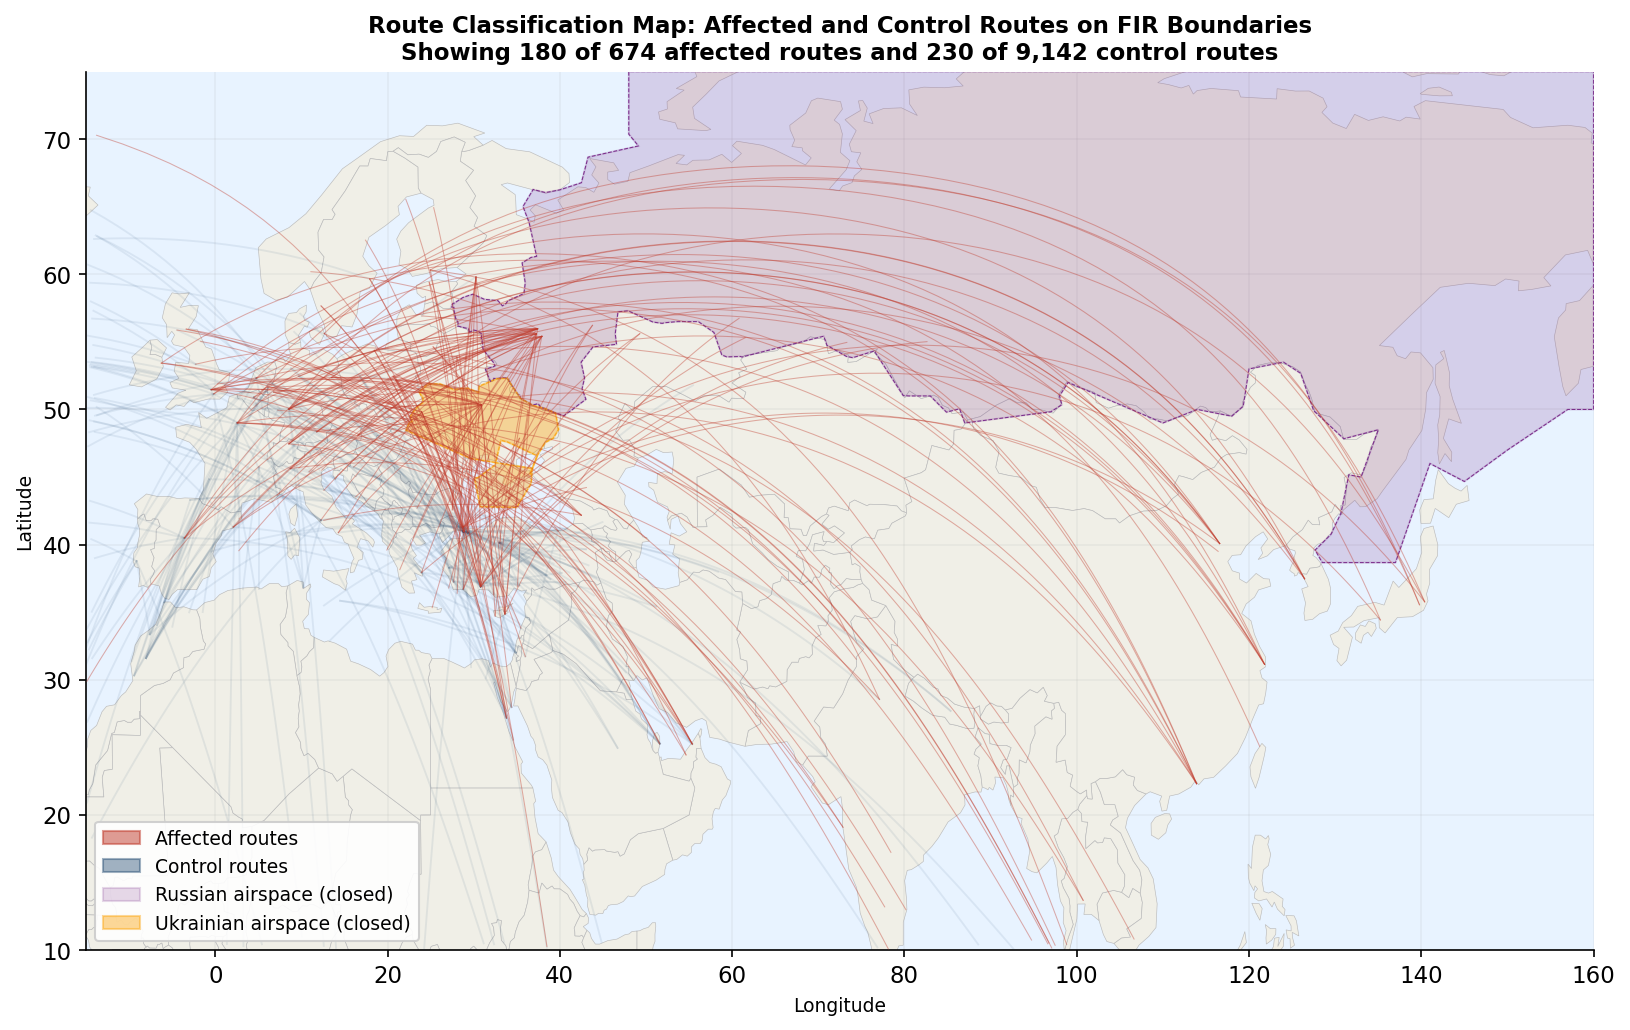

In [10]:
resp = requests.get(
    'https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson',
    timeout=30)
world = json.loads(resp.text)

def draw_basemap(ax):
    ax.set_facecolor("#DDEEFFAA")
    for feature in world['features']:
        geom  = feature['geometry']
        polys = [geom['coordinates']] if geom['type']=='Polygon' else geom['coordinates']
        for poly in polys:
            xs = [c[0] for c in poly[0]]; ys = [c[1] for c in poly[0]]
            ax.fill(xs, ys, color='#F0EFE7', edgecolor='#BBBBBB', linewidth=0.3, zorder=1)

def plot_poly(ax, geom, color, alpha_fill=0.18, lw=1.4):
    if geom.geom_type == 'Polygon':
        xs, ys = geom.exterior.xy
        ax.fill(xs, ys, color=color, alpha=alpha_fill, zorder=2)
        ax.plot(xs, ys, color=color, linewidth=lw, linestyle='--', zorder=3)
    elif geom.geom_type in ('MultiPolygon','GeometryCollection'):
        for g in geom.geoms:
            if hasattr(g, 'exterior'):
                plot_poly(ax, g, color, alpha_fill, lw)

def plot_route(ax, olat, olon, dlat, dlon, color, alpha, lw):
    pts  = great_circle_points(olat, olon, dlat, dlon, n=80)
    lons = [olon] + [p[1] for p in pts] + [dlon]
    lats = [olat] + [p[0] for p in pts] + [dlat]
    clipped = [(lo,la) for lo,la in zip(lons,lats) if -15<=lo<=160 and 10<=la<=75]
    if len(clipped) > 1:
        ax.plot([p[0] for p in clipped], [p[1] for p in clipped],
                color=color, alpha=alpha, linewidth=lw, zorder=4)

route_coords = (
    df_pivot[['AIRP_PR','ORIG_CC','DEST_CC',
              'ORIG_LAT','ORIG_LON','DEST_LAT','DEST_LON','AFFECTED']]
    .drop_duplicates('AIRP_PR')
    .dropna(subset=['ORIG_LAT','DEST_LAT'])
    .pipe(lambda df: df[~df['DEST_CC'].isin(EUROPEAN_DESTS)])
)
affected = route_coords[route_coords['AFFECTED']]
control  = route_coords[~route_coords['AFFECTED']]

NAVY = '#0F1F3D'; BLUE = "#153F69"; RED = "#C03A2BC9"; GOLD = "#FCA000CD"
LEGEND = [
    mpatches.Patch(color=RED,      alpha=0.5,  label='Affected routes'),
    mpatches.Patch(color=BLUE,     alpha=0.4,  label='Control routes'),
    mpatches.Patch(color='#7B2D8B',alpha=0.18, label='Russian airspace (closed)'),
    mpatches.Patch(color=GOLD,     alpha=0.40, label='Ukrainian airspace (closed)'),
]

n_affected_shown = round(len(affected) * 0.25)
n_control_shown  = round(len(control) * 0.1)

fig, ax = plt.subplots(figsize=(11, 7))
draw_basemap(ax)
ax.set_xlim(-15, 160); ax.set_ylim(10, 75)

map_extent     = sbox(-15, 10, 160, 75)
russia_clipped = RUSSIA_FIR.intersection(map_extent).difference(UKRAINE_FIR)
plot_poly(ax, russia_clipped, '#7B2D8B', alpha_fill=0.18, lw=0.5)
plot_poly(ax, UKRAINE_FIR,    GOLD, alpha_fill=0.35, lw=0.5)

for _, row in control.sample(frac=0.1, random_state=42).iterrows():
    plot_route(ax, row.ORIG_LAT, row.ORIG_LON, row.DEST_LAT, row.DEST_LON, BLUE, alpha=0.08, lw=0.9)
for _, row in affected.sample(frac=0.25, random_state=42).iterrows():
    plot_route(ax, row.ORIG_LAT, row.ORIG_LON, row.DEST_LAT, row.DEST_LON, RED,  alpha=0.40, lw=0.5)

ax.legend(handles=LEGEND, loc='lower left', fontsize=9, framealpha=0.9)
ax.set_title(f'Route Classification Map: Affected and Control Routes on FIR Boundaries\n'
             f'Showing {n_affected_shown} of 674 affected routes and {n_control_shown} of 9,142 control routes', 
             fontsize=11, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=9); ax.set_ylabel('Latitude', fontsize=9)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_route_map.png', dpi=180, bbox_inches='tight')
plt.show()

## 9. Save panels

In [11]:
df_pivot.to_parquet(CLEAN_DIR / 'route_panel_full.parquet', index=False)
route_panel_nc.to_parquet(CLEAN_DIR / 'route_panel_nc.parquet', index=False)
print(f'Saved route_panel_full: {df_pivot.shape}')
print(f'Saved route_panel_nc:   {route_panel_nc.shape}')


Saved route_panel_full: (885377, 31)
Saved route_panel_nc:   (783057, 31)
